In [2]:
import pandas as pd

# Load CSV while ignoring metadata lines
df = pd.read_csv("/media/hp/TOSHIBA EXT/TOI.csv", comment='#')

# Show first few rows
print(df.head())

# Show column names
print(df.columns)

# Check dataset size
print("Total entries:", len(df))

# Check distribution of classes
print(df['tfopwg_disp'].value_counts())

       toi        tid tfopwg_disp         rastr          ra         decstr  \
0  1000.01   50365310          FP  07h29m25.85s  112.357708  -12d41m45.46s   
1  1001.01   88863718          PC  08h10m19.31s  122.580465  -05d30m49.87s   
2  1002.01  124709665          FP  06h58m54.47s  104.726966  -10d34m49.64s   
3  1003.01  106997505          FP  07h22m14.39s  110.559945  -25d12m25.26s   
4  1004.01  238597883          FP  08h08m42.77s  122.178195  -48d48m10.12s   

         dec  st_pmra  st_pmraerr1  st_pmraerr2  ...  st_logg  st_loggerr1  \
0 -12.695960   -5.964        0.085       -0.085  ...     4.19         0.07   
1  -5.513852   -4.956        0.102       -0.102  ...     4.03         0.09   
2 -10.580455   -1.462        0.206       -0.206  ...      NaN          NaN   
3 -25.207017   -0.939        0.041       -0.041  ...     4.15         1.64   
4 -48.802811   -4.496        0.069       -0.069  ...     4.14         0.07   

   st_loggerr2  st_logglim   st_rad  st_raderr1  st_raderr2  s

Original size: 7913
After cleaning: 7269
After filtering: 696
tfopwg_disp
PC     327
CP     198
FP     100
KP      28
FA      23
APC     20
Name: count, dtype: int64


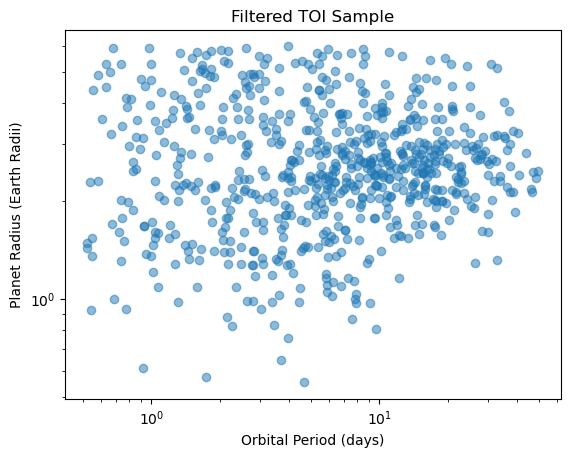

In [4]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("/media/hp/TOSHIBA EXT/TOI.csv", comment='#')

# =========================
# SELECT IMPORTANT COLUMNS
# =========================
cols = [
    'toi', 'tfopwg_disp',
    'pl_orbper', 'pl_rade', 'pl_trandep', 'pl_trandurh',
    'st_tmag', 'st_teff', 'st_rad'
]

df = df[cols]

# =========================
# REMOVE MISSING VALUES
# =========================
df_clean = df.dropna()

print("Original size:", len(df))
print("After cleaning:", len(df_clean))

# =========================
# APPLY SCIENTIFIC FILTERS
# =========================

filtered = df_clean[
    (df_clean['pl_rade'] < 6) &          # Sub-Neptune planets
    (df_clean['pl_orbper'] > 0.5) &      # Remove ultra-short noise
    (df_clean['pl_orbper'] < 50) &       # Avoid poorly constrained long periods
    (df_clean['st_tmag'] < 10)           # Bright stars
]

print("After filtering:", len(filtered))

print(filtered['tfopwg_disp'].value_counts())

import matplotlib.pyplot as plt

plt.figure()

plt.scatter(filtered['pl_orbper'], filtered['pl_rade'], alpha=0.5)

plt.xlabel("Orbital Period (days)")
plt.ylabel("Planet Radius (Earth Radii)")
plt.title("Filtered TOI Sample")

plt.xscale('log')
plt.yscale('log')

plt.show()